# Mental Health in Tech
## 0. Overview

### Importing

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import re

In [3]:
import sqlite3 as sql
database = 'database/mental_health.sqlite'
con = sql.connect(database)

## Overview of Database

In [4]:
answers = pd.read_sql('SELECT * FROM Answer', con)
survey = pd.read_sql('SELECT * FROM Survey', con)
questions = pd.read_sql('SELECT * FROM question', con)

print('Questions db shape: '+ str(questions.shape))
print('Answers db shape: '+ str(answers.shape))
print('Survey db shape: '+ str(survey.shape))

Questions db shape: (105, 2)
Answers db shape: (236898, 4)
Survey db shape: (5, 2)


We can surmise what questions and answer databases contain, what about the Survey table?

In [5]:
query = """SELECT * 
           FROM Survey"""

run_sql = pd.read_sql(query, con)
run_sql

,SurveyID,Description
0,2014,mental health survey for 2014
1,2016,mental health survey for 2016
2,2017,mental health survey for 2017
3,2018,mental health survey for 2018
4,2019,mental health survey for 2019


The **Survey** table contains labelling and IDs of the **year** conducted.

### Questions

In [6]:
query = """
SELECT *
FROM Question"""

run_sql = pd.read_sql(query, con)
run_sql

,questiontext,questionid
0,What is your age?,1
1,What is your gender?,2
2,What country do you live in?,3
3,"If you live in the United States, which state ...",4
4,Are you self-employed?,5
...,...,...
100,Do you think that team members/co-workers woul...,114
101,"If yes, what condition(s) have you been diagno...",115
102,"If maybe, what condition(s) do you believe you...",116
103,Which of the following best describes your wor...,117


There are over 100 questions amongst the surveys, and after careful deliberation, only a select few questions were filtered for the use of this notebook and research.

The specific area of interest will be:  *( INSERT HERE )*

In [7]:
query = """
        SELECT SurveyID AS year,
        COUNT(DISTINCT QuestionID) AS num_questions
        FROM Answer
        GROUP BY SurveyID
        ORDER BY SurveyID;
        """

run_sql = pd.read_sql_query(query, con)
run_sql

,year,num_questions
0,2014,26
1,2016,60
2,2017,76
3,2018,76
4,2019,76


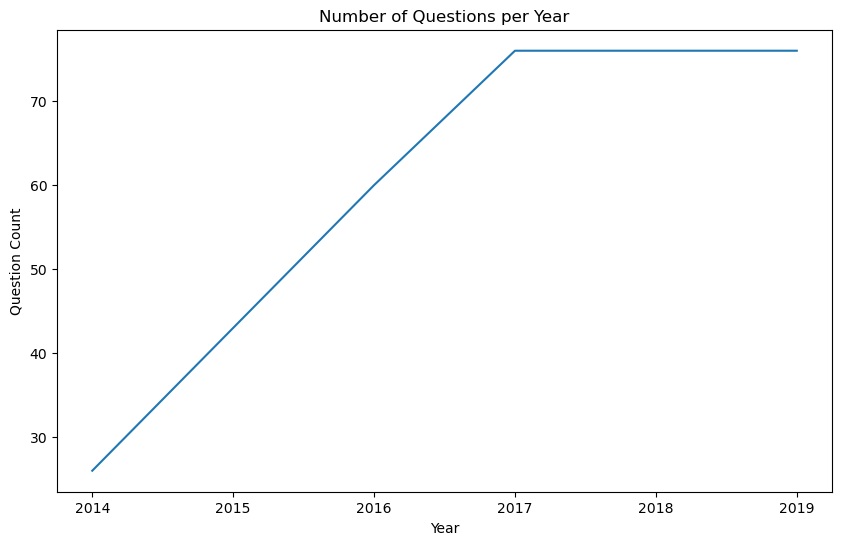

In [8]:
plt.figure(figsize=(10, 6))
sns.lineplot(run_sql, x='year', y='num_questions')
plt.title('Number of Questions per Year')
plt.xlabel('Year')
plt.ylabel('Question Count')
plt.show()

Over the years, the number of questions asked has considerably increased since 2014, and 76 questions became the standard since 2017.

### Respondents

In [9]:
query = """SELECT SurveyID AS year, 
                  COUNT(DISTINCT UserID) AS num_respondents
           FROM Answer
           WHERE QuestionID = 2
           GROUP BY SurveyID
        """

run_sql = pd.read_sql(query, con)
run_sql

,year,num_respondents
0,2014,1260
1,2016,1433
2,2017,756
3,2018,417
4,2019,352


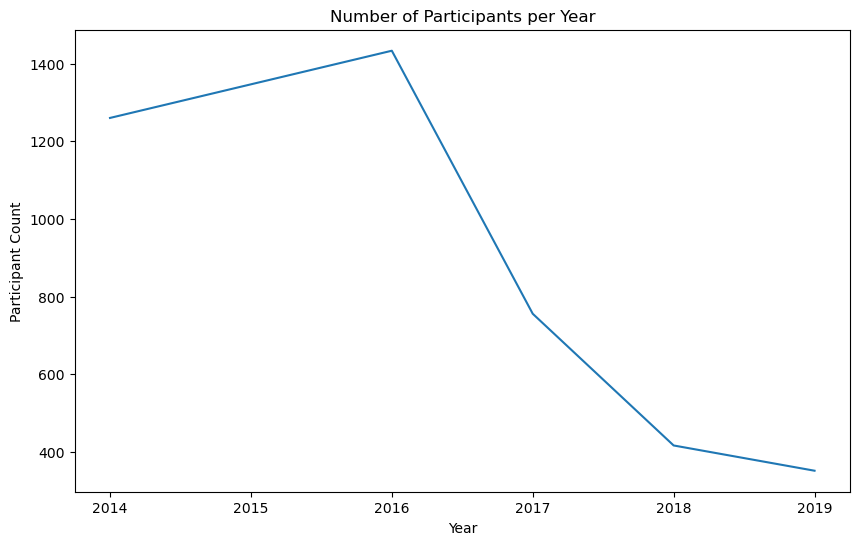

In [10]:
plt.figure(figsize=(10, 6))
sns.lineplot(run_sql, x='year', y='num_respondents')
plt.title('Number of Participants per Year')
plt.xlabel('Year')
plt.ylabel('Participant Count')
plt.show()

## 1. Sociodemographical Analysis

### 1.1 Age

In [11]:
query = """WITH age_group AS(
            SELECT SurveyID AS year,
                CASE
                    WHEN CAST(AnswerText AS INTEGER) BETWEEN 18 AND 24 THEN '18-24'
                    WHEN CAST(AnswerText AS INTEGER) BETWEEN 25 AND 34 THEN '25-34'
                    WHEN CAST(AnswerText AS INTEGER) BETWEEN 35 AND 44 THEN '35-44'
                    WHEN CAST(AnswerText AS INTEGER) BETWEEN 45 AND 54 THEN '45-54'
                    WHEN CAST(AnswerText AS INTEGER) BETWEEN 55 AND 64 THEN '55-64'
                    WHEN CAST(AnswerText AS INTEGER) BETWEEN 65 AND 99 THEN '65+'
                END AS age_group,
                COUNT(*) AS count
            FROM Answer
            WHERE QuestionID = 1
                AND CAST(AnswerText AS INTEGER) BETWEEN 18 AND 99
            GROUP BY SurveyID, age_group
            )
        SELECT *
        FROM age_group
        """

df_ages = pd.read_sql(query, con)
df_ages.head()

,year,age_group,count
0,2014,18-24,156
1,2014,25-34,707
2,2014,35-44,321
3,2014,45-54,51
4,2014,55-64,15


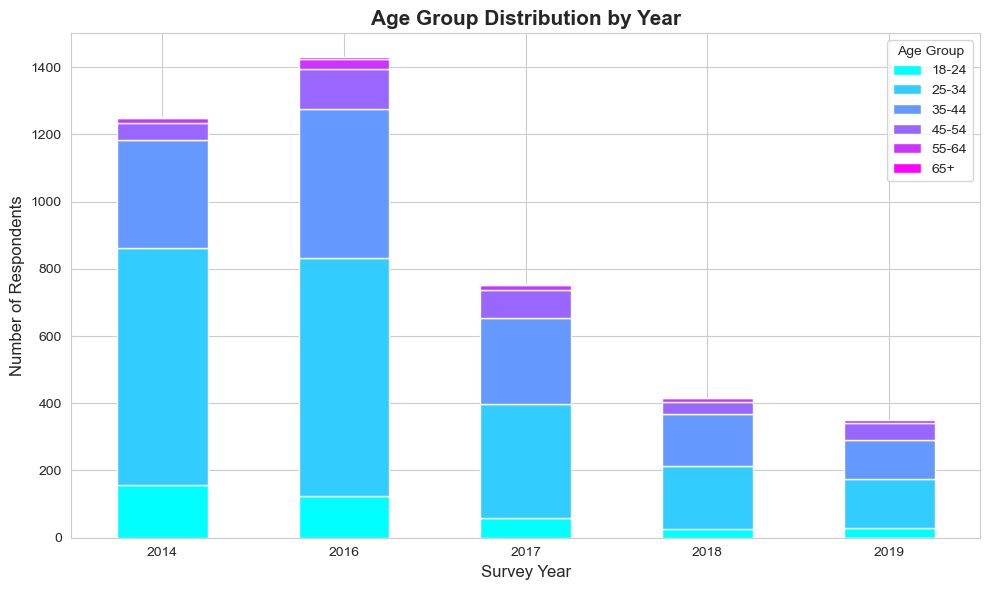

In [48]:
df_wide = df_ages.pivot(index='year', columns='age_group', values='count').fillna(0)

fig, ax = plt.subplots(figsize=(10, 6))

df_wide.plot(kind="bar", stacked=True, ax=ax, colormap='cool')

ax.set_ylabel('Number of Respondents', size=12)
ax.set_xlabel('Survey Year', size=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.title('Age Group Distribution by Year', size=15, weight='bold')

labels_legend = df_wide.columns.tolist()  
ax.legend(labels=labels_legend, title="Age Group")

plt.tight_layout()
plt.show()

### 2.2 Gender

In [13]:
query = """
        SELECT  SurveyID AS year, 
                AnswerText AS gender, 
                COUNT(*) AS count
        FROM Answer
        WHERE QuestionID = 2
        GROUP BY SurveyID, AnswerText
        ORDER BY SurveyID, count DESC"""

df_gender = pd.read_sql(query, con)
df_gender.head()

,year,gender,count
0,2014,Male,991
1,2014,Female,247
2,2014,Female (trans),2
3,2014,something kinda male?,1
4,2014,queer/she/they,1


#### Data Cleaning for gender category

In [14]:
def categorize_gender(text):
    if not isinstance(text, str):
        return "other"
    
    t = text.lower()

    female = ["female", "woman", "afab", "girl", "f", "fem", "mtf", "she", "her"]
    male = ["male", "man", "amab", "boy", "guy", "m", "masc", "ftm", "he","him"]

    if any(re.search(rf"\b{w}\b", t) for w in male):
        return "male"
    elif any(re.search(rf"\b{w}\b", t) for w in female):
        return "female"
    else:
        return "other"

In [15]:
df_gender['gender'] = df_gender['gender'].apply(categorize_gender)
df_gender = df_gender.groupby(['year', 'gender'])['count'].sum().reset_index()

df_gender['percent'] = (df_gender['count'] / df_gender.groupby('year')['count'].transform('sum') * 100).round(1)
df_gender.head()

,year,gender,count,percent
0,2014,female,252,20.0
1,2014,male,996,79.0
2,2014,other,12,1.0
3,2016,female,345,24.1
4,2016,male,1060,74.0


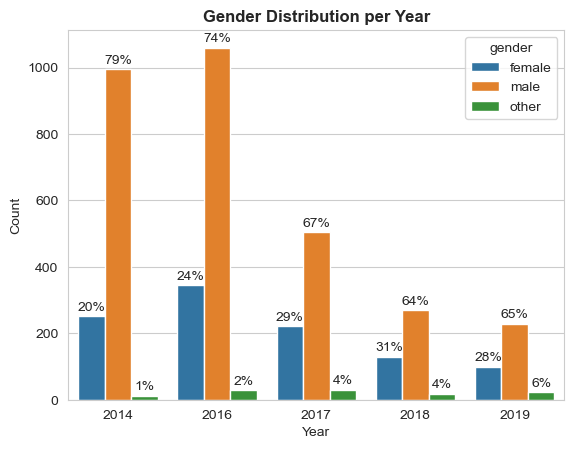

In [50]:
ax = sns.barplot(df_gender, x='year', y='count', hue='gender', errorbar=None)

percent_labels = df_gender['percent'].round(0).astype(int).astype(str) + '%'

ax.bar_label(ax.containers[0], labels=percent_labels[df_gender['gender'] == 'female'].values, padding=2)
ax.bar_label(ax.containers[1], labels=percent_labels[df_gender['gender'] == 'male'].values, padding=2)
ax.bar_label(ax.containers[2], labels=percent_labels[df_gender['gender'] == 'other'].values, padding=2)

plt.xlabel('Year')
plt.ylabel('Count')
plt.title('Gender Distribution per Year', weight='bold')

plt.show()

### 2.3 Country Demographics

In [17]:
query = """
        SELECT  SurveyID AS year, 
                AnswerText AS country, 
                COUNT(*) AS count
        FROM Answer
        WHERE QuestionID = 3
        GROUP BY SurveyID, AnswerText
        ORDER BY SurveyID, count DESC
        """

df_country = pd.read_sql(query, con)
df_country.head()

,year,country,count
0,2014,United States,751
1,2014,United Kingdom,185
2,2014,Canada,72
3,2014,Germany,45
4,2014,Netherlands,27


In [18]:
df_country['country'] = df_country['country'].replace({'United States': 'United States of America'})

Text(0.5, 1.0, "Respondents' Country of Residence")

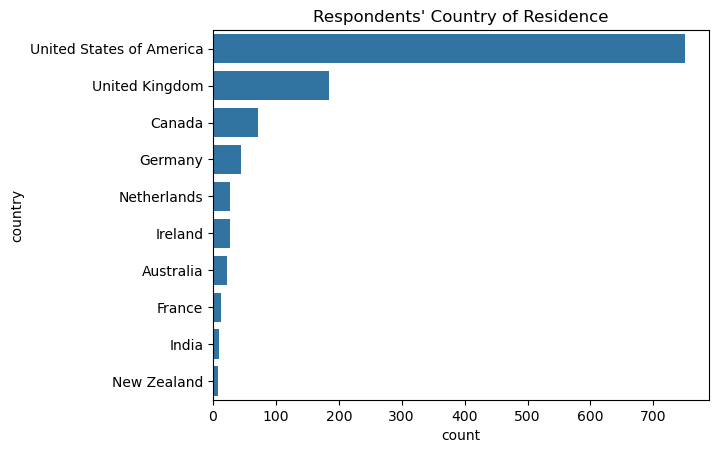

In [19]:
sns.barplot(df_country.head(10), x='count', y='country')
plt.title("Respondents' Country of Residence")

### 2.4 Race Demographics

Note: This question was only gathered in 2017 onwards.

In [20]:
query = """WITH Race AS (
            SELECT 
                SurveyID AS year, 
                CASE
                    WHEN AnswerText IN ('-1', 'I prefer not to answer') THEN NULL
                    WHEN AnswerText IN ('White Hispanic', 'European American', 'More than one of the above') THEN 'Mixed'
                    ELSE AnswerText
                END AS race
            FROM Answer
            WHERE QuestionID = 89
        )
            SELECT year, race, COUNT(*) AS count
            FROM Race
            GROUP BY year, race
            ORDER BY year, count DESC"""

df_race = pd.read_sql(query, con)
df_race.head()

,year,race,count
0,2017,White,435
1,2017,None,288
2,2017,Mixed,14
3,2017,Asian,13
4,2017,Black or African American,6


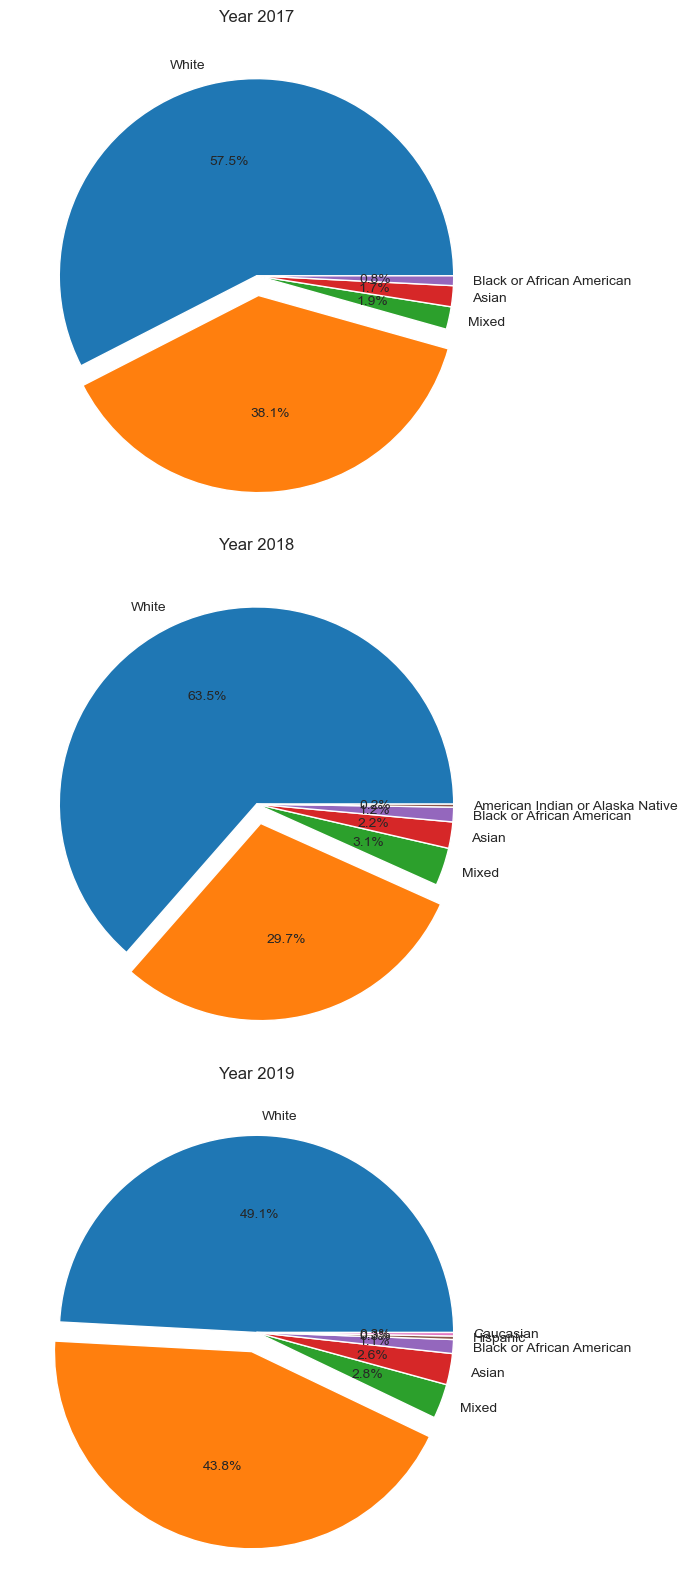

In [21]:
sns.set_style("whitegrid")

years = df_race['year'].unique()
num_years = len(years)

fig, axes = plt.subplots(3, 1, figsize=(10, 16))

axes = axes.flatten()

for i, year in enumerate(years):
    ax = axes[i]
    df_year = df_race[df_race['year'] == year]

    explode = [0] * len(df_year)
    explode[1] = 0.1


    ax.pie(df_year['count'], labels=df_year['race'], autopct='%1.1f%%', explode=explode)
    ax.set_title(f'Year {year}')

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Interestingly enough, a large percent chose not to answer this question

## 3. Prevalence Rate

*(In a plot, report the prevalence rate of at least three mental diseases.)*

*(Make sure to plot the confidence interval and provide its interpretation.)*

Questions in use in this section:

- #34 Have you ever been diagnosed with a mental health disorder? (1570 respondents - 806 51% yes | 764 48.7% no)
- **(#115) If yes, what condition(s) have you been diagnosed with? (652 respondents, 2072 total responses (multi-select allowed))**

### 3.1 Diagnosed Cases

In [22]:
query = """
        SELECT  AnswerText AS condition,
                COUNT(DISTINCT UserID) AS count
        FROM Answer 
        WHERE QuestionID = 115
        GROUP BY AnswerText
        ORDER BY count DESC;
        """

df_conditions_all = pd.read_sql(query, con)
df_conditions_all.head()

,condition,count
0,-1,865
1,"Mood Disorder (Depression, Bipolar Disorder, etc)",412
2,"Anxiety Disorder (Generalized, Social, Phobia,...",345
3,Attention Deficit Hyperactivity Disorder,121
4,Post-traumatic Stress Disorder,69


There are 12 fixed responses (and 1 "Other" choice) to choose from. To progress our analysis, I will be categorizing the free responses to one of the 12 fixed responses with regards to the source and in line with medical research as close as possible. Sources: 

There are 23 free responses that had to be categorized

In [23]:
categories_dict = {
    "Mood Disorder (Depression, Bipolar Disorder, etc)": ["depression", "seasonal affective disorder"],
    "Anxiety Disorder (Generalized, Social, Phobia, etc)": ["anxiety"],
    "Attention Deficit Hyperactivity Disorder": ["add", "adhd"],
    "Post-traumatic Stress Disorder": ["ptsd"],
    "Obsessive-Compulsive Disorder": ["ocd"],
    "Substance Use Disorder": ["alcohol", "drug", "substance"],
    "Personality Disorder (Borderline, Antisocial, Paranoid, etc)": [],
    "Stress Response Syndromes": [],
    "Addictive Disorder": ["sexual addiction", "addiction"],
    "Eating Disorder (Anorexia, Bulimia, etc)": [],
    "Dissociative Disorder": ["depersonalization", "dissociative"],
    "Psychotic Disorder (Schizophrenia, Schizoaffective, etc)": ["schizo", "psychosis"],
    "Autism Spectrum Disorder (ASD)": ["autism", "asperges", "asperger", "pervasive", "pdd"]
}

def categorize_condition(text):
    if not isinstance(text, str) or not text.strip():
        return -1
    
    if text in categories_dict:
        return text

    text = text.lower().strip()

    drop_terms = [
        "transgender", "gender", "tinnitus", "traumatic brain injury", "sleeping disorder", "burn out", "burnout", "hurt", "haven't been formally diagnosed", "undiagnosed"
    ]
    if any(term in text for term in drop_terms):
        return -1
    
    for category, keywords in categories_dict.items():
        if any(keyword in text for keyword in keywords):
            return category
        
    return -1

In [24]:
df_conditions = df_conditions_all.copy()
df_conditions["condition"] = df_conditions_all["condition"].apply(categorize_condition)
df_conditions = df_conditions[df_conditions["condition"] != -1]

df_conditions = (df_conditions.groupby("condition", as_index=False)["count"]
                .sum()
                .sort_values(by=["count"], ascending=[False]))

df_conditions = df_conditions.reset_index(drop=True)
df_conditions.head()

,condition,count
0,"Mood Disorder (Depression, Bipolar Disorder, etc)",414
1,"Anxiety Disorder (Generalized, Social, Phobia,...",345
2,Attention Deficit Hyperactivity Disorder,124
3,Post-traumatic Stress Disorder,69
4,Obsessive-Compulsive Disorder,45


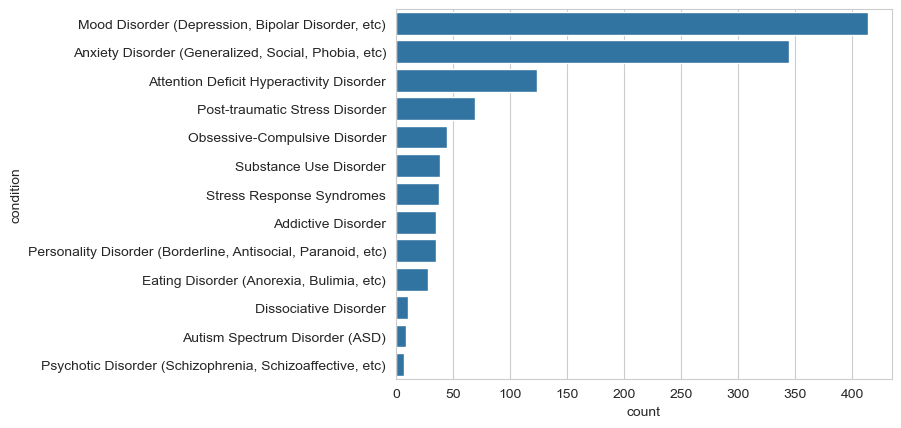

In [25]:
sns.barplot(df_conditions, x="count", y="condition")
plt.show()

### 3.2 Prevalence Rate Plotting

In [26]:
df_conditions['prevalence (%)'] = (((df_conditions['count']) / 1433) * 100)
df_conditions

,condition,count,prevalence (%)
0,"Mood Disorder (Depression, Bipolar Disorder, etc)",414,28.890440
1,"Anxiety Disorder (Generalized, Social, Phobia,...",345,24.075366
2,Attention Deficit Hyperactivity Disorder,124,8.653175
3,Post-traumatic Stress Disorder,69,4.815073
4,Obsessive-Compulsive Disorder,45,3.140265
5,Substance Use Disorder,39,2.721563
6,Stress Response Syndromes,38,2.651779
7,Addictive Disorder,35,2.442428
8,"Personality Disorder (Borderline, Antisocial, ...",35,2.442428
9,"Eating Disorder (Anorexia, Bulimia, etc)",28,1.953943


In [27]:
from statsmodels.stats.proportion import proportion_confint

n = 1433 

ci = df_conditions['count'].apply(lambda x: proportion_confint(count=x, nobs=n, alpha=0.05, method='wilson'))

df_conditions['ci_lower'] = [x[0] for x in ci]
df_conditions['ci_upper'] = [x[1] for x in ci]

df_conditions['ci_lower (%)'] = df_conditions['ci_lower'] * 100
df_conditions['ci_upper (%)'] = df_conditions['ci_upper'] * 100

df_conditions[['condition', 'prevalence (%)', 'ci_lower (%)', 'ci_upper (%)']]

,condition,prevalence (%),ci_lower (%),ci_upper (%)
0,"Mood Disorder (Depression, Bipolar Disorder, etc)",28.890440,26.602591,31.291163
1,"Anxiety Disorder (Generalized, Social, Phobia,...",24.075366,21.932933,26.356421
2,Attention Deficit Hyperactivity Disorder,8.653175,7.305810,10.221626
3,Post-traumatic Stress Disorder,4.815073,3.822352,6.049402
4,Obsessive-Compulsive Disorder,3.140265,2.355110,4.175983
5,Substance Use Disorder,2.721563,1.997202,3.698726
6,Stress Response Syndromes,2.651779,1.938016,3.618718
7,Addictive Disorder,2.442428,1.761361,3.377791
8,"Personality Disorder (Borderline, Antisocial, ...",2.442428,1.761361,3.377791
9,"Eating Disorder (Anorexia, Bulimia, etc)",1.953943,1.355287,2.809505


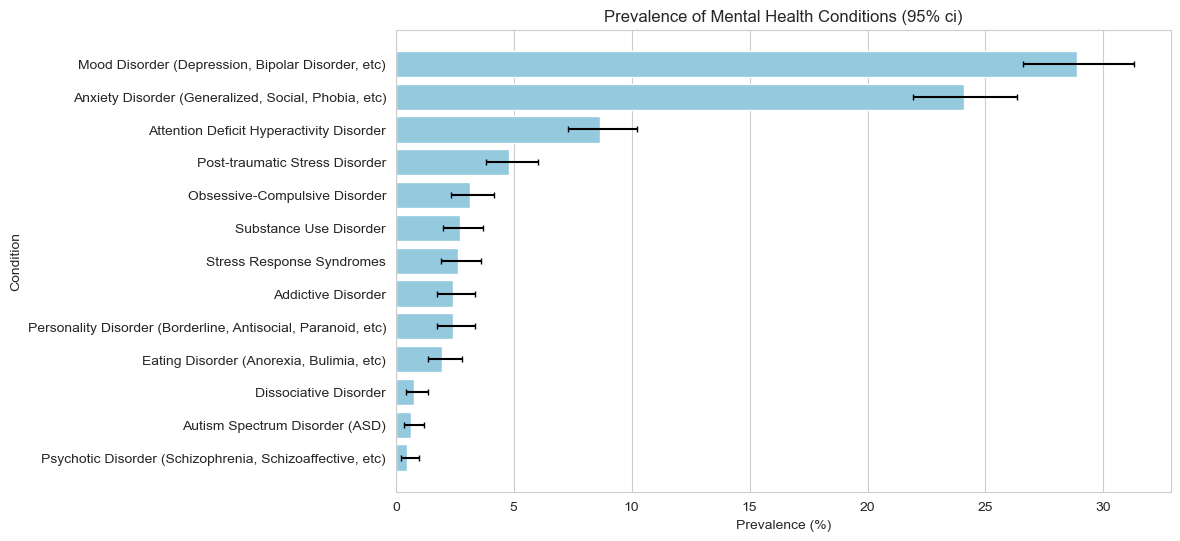

In [28]:
plt.figure(figsize=(10,6))
ax = sns.barplot(df_conditions, x='prevalence (%)', y='condition', color='skyblue')

plt.errorbar(
    x=df_conditions['prevalence (%)'],
    y=range(len(df_conditions)),
    xerr=[
        df_conditions['prevalence (%)'] - df_conditions['ci_lower (%)'],
        df_conditions['ci_upper (%)'] - df_conditions['prevalence (%)']
    ],
    fmt='none',        
    ecolor='black',
    capsize=2
)

plt.title('Prevalence of Mental Health Conditions (95% ci)')
plt.xlabel('Prevalence (%)')
plt.ylabel('Condition')
plt.show()

## 4.

## 5. Final Insights
### 5.1 Suggestions for Research

### 5.2 Conclusion